<a href="https://colab.research.google.com/github/owenjiao0129-png/pythonAI/blob/main/face_door_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚪 刷臉門禁系統（PyTorch．資料夾版）

### 這堂課要做一件事

你會建一個**刷臉門禁**，然後拿同一張照片刷**兩次**：

| | 結果 |
|---|---|
| 🔴 **訓練前** 刷臉 | ❌ 拒絕進入 |
| 🟢 **訓練後** 刷臉 | ✅ 歡迎回來 |

**照片沒變，程式沒變，模型物件也沒換。**
變的只有**權重那幾個數字**。這就是「訓練 AI」的全部意義。

---

## 📁 開始前：先把照片放好

**這個版本不用一張一張上傳。** 你只要把照片照下面的結構擺好，程式會自己去掃。

```
AI_door/                     ← 你的資料夾（名字可以自己取）
│
├── faces/                   ← 訓練資料放這裡
│   ├── me/                  ← 資料夾名稱 = 這個人的名字
│   │   ├── 001.jpg          （15 張以上）
│   │   ├── 002.jpg
│   │   └── ...
│   └── others/              ← 「不放行的人」，這個名字請照抄
│       ├── a.jpg            （20 張以上，至少 3 個不同的人）
│       └── ...
│
└── test/                    ← 測試照放這裡（不要跟 faces/ 重複！）
    ├── demo.jpg             ← 訓練前刷這張，訓練後再刷一次同一張
    └── stranger.jpg         ← 壓力測試用
```

> 💡 **資料夾名稱就是類別名稱。**
> 想改名字？改資料夾名稱就好。
> 想加第三個人（例如室友）？**多開一個 `roommate/` 資料夾就好，程式一行都不用改。**

> ⚠️ **資料夾名稱建議用英文。**
> 因為它會被拿去當圖表標題，而 Colab 預設沒有中文字型 ——
> 用中文的話圖表上會出現一排豆腐字 □□□。（程式本身不受影響，純粹是好看問題。）

---

### ⚠️ 最重要的一件事：照片存在哪裡？

| 存在哪 | 關掉分頁之後 |
|---|---|
| `/content/`（Colab 暫存） | ❌ **全部消失** |
| **Google Drive**（掛載） | ✅ **永久留著** ← 推薦 |
| **本機資料夾**（VS Code / Jupyter） | ✅ **永久留著** |

**如果你想要照片留著，下一格請選 Google Drive。**
第一次會跳出授權視窗，按同意就好 —— 它只會存取你自己的雲端硬碟。

---

### 挑照片的重點

- 不同角度、不同表情、不同光線
- 臉要**夠大、夠清楚、正面**（側臉偵測會失敗）
- 一張照片裡最好只有一張臉

> 🔒 放別人的照片前請先問過對方。人臉是生物特徵資料，這不只是禮貌問題。

---
## 0️⃣ 環境準備

Colab 已經內建 PyTorch，不用安裝。

**記得先開 GPU**：上方選單 → 執行階段 → 變更執行階段類型 → T4 GPU
（沒開也能跑，只是慢一點）

In [ ]:
import os, glob, time, shutil
from base64 import b64encode

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import models, transforms

from IPython.display import display, HTML

# 中文字型（讓圖表能顯示中文）
try:
    !apt-get -qq install fonts-noto-cjk > /dev/null 2>&1
    import matplotlib.font_manager as fm
    fm.fontManager = fm.FontManager()
    for cand in ['Noto Sans CJK TC', 'Noto Sans CJK JP', 'Noto Sans CJK SC']:
        if any(f.name == cand for f in fm.fontManager.ttflist):
            plt.rcParams['font.family'] = cand
            break
except Exception:
    pass
plt.rcParams['axes.unicode_minus'] = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

IN_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in dir() else False

print('✅ 環境就緒')
print('   PyTorch:', torch.__version__)
print('   裝置:', DEVICE, '←', 'GPU 有開' if DEVICE.type == 'cuda' else 'CPU（會慢一點，但沒關係）')
print('   環境:', 'Google Colab' if IN_COLAB else '本機（VS Code / Jupyter）')

✅ 環境就緒
   PyTorch: 2.11.0+cu128
   裝置: cuda ← GPU 有開
   環境: Google Colab


---
## 1️⃣ 設定照片資料夾

**選 Google Drive 的話，照片會永久留著，下次打開直接跑。**

第一次執行會跳出授權視窗 → 按「連線至 Google 雲端硬碟」→ 選你的帳號 → 允許。

In [ ]:
#@title 📁 設定資料夾位置 { display-mode: "both" }

#@markdown **照片存在哪裡？**
#@markdown * `drive` — Google 雲端硬碟：**永久保存（推薦）**
#@markdown * `colab` — Colab 暫存：關掉分頁就消失
#@markdown * `local` — 本機資料夾：VS Code / Jupyter
storage = "drive"  #@param ["drive", "colab", "local"]

#@markdown **資料夾名稱**（要跟 `1_prepare_dataset.ipynb` 填一樣的）
folder_name = "AI_door"  #@param {type:"string"}

if storage == 'drive':
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = os.path.join('/content/drive/MyDrive', folder_name)
elif storage == 'colab':
    ROOT = os.path.join('/content', folder_name)
else:
    ROOT = os.path.abspath(folder_name)          # 跟這個 notebook 同一層

FACES_DIR = os.path.join(ROOT, 'faces')
TEST_DIR = os.path.join(ROOT, 'test')
os.makedirs(FACES_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

print('📂 資料夾位置：')
print(f'   訓練資料 → {FACES_DIR}')
print(f'   測試照片 → {TEST_DIR}')

if storage == 'drive':
    print(f'\n💾 這些照片會永久留在你的雲端硬碟裡')
    print(f'   在 Drive 網頁版打開「我的雲端硬碟 / {folder_name}」就能直接拖照片進去')
elif storage == 'colab':
    print('\n⚠️ 注意：這是暫存空間，關掉分頁後照片會全部消失！')
    print('   左邊「檔案」圖示可以拖照片進去，但只留到這次連線結束')
else:
    print(f'\n💾 這些照片跟 notebook 放在一起，永久留著')

Mounted at /content/drive
📂 資料夾位置：
   訓練資料 → /content/drive/MyDrive/AI_door/faces
   測試照片 → /content/drive/MyDrive/AI_door/test

💾 這些照片會永久留在你的雲端硬碟裡
   在 Drive 網頁版打開「我的雲端硬碟 / AI_door」就能直接拖照片進去


### 檢查照片放對了沒

執行下面這格。它會掃描你的資料夾，告訴你每個人有幾張照片。

**如果顯示「還沒有任何資料夾」**，代表照片還沒放進去 ——
按照上面的結構把照片放好（或用再下面那格上傳），然後重跑這一格。

In [ ]:
IMG_EXTS = ('*.jpg', '*.jpeg', '*.png', '*.webp', '*.bmp',
            '*.JPG', '*.JPEG', '*.PNG')

def list_images(folder):
    """列出資料夾裡所有圖片。用 set 去重，因為 Windows/Mac 的檔案系統不分大小寫。"""
    files = []
    for ext in IMG_EXTS:
        files += glob.glob(os.path.join(folder, ext))
    return sorted(set(files))

def scan_dataset(root):
    """掃描 faces/ 底下每一個子資料夾。資料夾名稱 = 類別名稱。

    空資料夾會自動忽略 —— 一個 0 張照片的類別對模型沒有意義，
    留著只會讓訓練爆掉。
    """
    if not os.path.isdir(root):
        return {}
    names = sorted(d for d in os.listdir(root)
                   if os.path.isdir(os.path.join(root, d))
                   and not d.startswith('.'))          # 濾掉 .DS_Store 這種
    found = {n: list_images(os.path.join(root, n)) for n in names}
    empty = [n for n, files in found.items() if not files]
    if empty:
        print(f'ℹ️ 忽略空資料夾：{empty}（沒有照片，不算一個類別）\n')
    return {n: files for n, files in found.items() if files}


dataset = scan_dataset(FACES_DIR)

if not dataset:
    print('📭 faces/ 裡還沒有任何資料夾\n')
    print('請建立這樣的結構：')
    print(f'   {FACES_DIR}/')
    print('     ├── <名字>/    ← 放 15 張以上「要放行的人」的照片')
    print('     └── others/    ← 放 20 張以上別人的照片')
    print('\n（或用下面那格上傳，它會自動幫你建好資料夾）')
else:
    print(f'📂 掃描 {FACES_DIR}\n')
    for name, files in dataset.items():
        bar = '█' * min(len(files) // 2, 30)
        print(f'   {name:<10} {len(files):>3} 張  {bar}')

    print()
    if 'others' not in dataset:
        print('⚠️ 找不到 others/ 資料夾！模型至少要有兩類才學得會分辨。')
    if len(dataset) < 2:
        print('⚠️ 至少要有 2 個資料夾。只給它看一個人，它只會回答「是你」——')
        print('   那不叫 AI，那叫 return True。')
    for name, files in dataset.items():
        if len(files) < 10:
            print(f'⚠️ 「{name}」只有 {len(files)} 張，太少了，建議再多放一些')

test_files = list_images(TEST_DIR)
print(f'\n📸 test/ 裡有 {len(test_files)} 張測試照：')
for f in test_files:
    print(f'   • {os.path.basename(f)}')
if not test_files:
    print('   ⚠️ 還沒有測試照！放一張你的正面照到 test/ 資料夾')

📂 掃描 /content/drive/MyDrive/AI_door/faces

   Colin_Powell  25 張  ████████████
   others      40 張  ████████████████████


📸 test/ 裡有 2 張測試照：
   • demo.jpg
   • stranger.jpg


### （備用）從電腦上傳照片到資料夾

**照片已經放好的話，跳過這格。**

這格是給「懶得開 Drive 網頁版拖檔案」的人用的 ——
它會把上傳的照片直接存進上面設定的資料夾，所以**一樣是永久保存**。

In [ ]:
#@title 📤 （備用）上傳照片到資料夾 { display-mode: "both" }

#@markdown **要存進哪一類？**
#@markdown * `faces` — 訓練資料（會存進 `faces/<下面填的名字>/`）
#@markdown * `test` — 測試照片（會存進 `test/`）
upload_to = "faces"  #@param ["faces", "test"]

#@markdown **人名 / 資料夾名稱**（`upload_to = test` 時這欄會被忽略）
person_name = "your_name"  #@param {type:"string"}

from google.colab import files

target = os.path.join(FACES_DIR, person_name) if upload_to == 'faces' else TEST_DIR

print(f'照片會存到：{target}')
print('請選擇檔案（可一次多選）')
up = files.upload()

# ⚠️ 資料夾一定要等「真的有選到檔案」才建。
#    如果先 makedirs 再上傳，使用者一按取消就會留下一個空資料夾，
#    然後掃描會把它當成一個 0 張照片的類別 —— 模型直接爆掉。
assert up, '❌ 沒有選到任何檔案（已取消）。沒有建立任何資料夾，可以放心。'
os.makedirs(target, exist_ok=True)

n = len(list_images(target))
ok = 0
for fname, content in up.items():
    arr = cv2.imdecode(np.frombuffer(content, np.uint8), cv2.IMREAD_COLOR)
    if arr is None:
        print(f'  ⚠️ 讀不到 {fname}，跳過'); continue
    if upload_to == 'faces':
        out = os.path.join(target, f'{n+ok:04d}.jpg')
    else:
        out = os.path.join(target, fname)      # 測試照保留原檔名，比較好認
    cv2.imwrite(out, arr)
    ok += 1

print(f'\n✅ 存進 {ok} 張，「{os.path.basename(target)}」現在共 {len(list_images(target))} 張')
print('👉 回上面那格重跑一次，確認掃描結果')

---
## 2️⃣ 建門禁系統的零件

門禁要做三件事：**找到臉 → 看懂臉 → 判斷是誰**。

這裡裝好前兩個。**還沒有任何訓練。**

In [ ]:
# ── 零件 A：人臉偵測（傳統演算法，不用訓練）──
detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def imread_unicode(path):
    """讀圖片。cv2.imread 遇到中文路徑會回傳 None，所以繞過去用 numpy 讀。"""
    try:
        data = np.fromfile(path, dtype=np.uint8)
        return cv2.imdecode(data, cv2.IMREAD_COLOR)
    except Exception:
        return None

def crop_face(img_bgr, size=224, margin=0.25):
    """找出圖中最大的一張臉，裁切成正方形。找不到回傳 None"""
    if img_bgr is None:
        return None
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
    if len(faces) == 0:
        return None
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    m = int(max(w, h) * margin)
    x1, y1 = max(0, x - m), max(0, y - m)
    x2, y2 = min(img_bgr.shape[1], x + w + m), min(img_bgr.shape[0], y + h + m)
    return cv2.resize(img_bgr[y1:y2, x1:x2], (size, size))

print('✅ 零件 A：人臉偵測器（不需訓練）')

✅ 零件 A：人臉偵測器（不需訓練）


In [ ]:
# ── 零件 B：看懂臉（別人訓練好的 CNN）──
# torchvision 0.13 之後改用 weights=，舊版是 pretrained=True。兩種都接。
try:
    backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
except AttributeError:
    backbone = models.mobilenet_v2(pretrained=True)

# mobilenet_v2 的 forward 是：features → avgpool → flatten → classifier
# 把 classifier 換成 Identity（什麼都不做），輸出就停在 1280 維的特徵向量
backbone.classifier = nn.Identity()
backbone = backbone.to(DEVICE).eval()
for p in backbone.parameters():
    p.requires_grad = False                # 🔒 凍結：不訓練它，只借用它的眼睛

preprocess = transforms.Compose([
    transforms.ToTensor(),                                  # HWC uint8 → CHW float [0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),        # ImageNet 的標準前處理
])

@torch.no_grad()                            # 不算梯度 → 省記憶體、跑更快
def to_embedding(faces_bgr, batch=32):
    """把人臉圖片（BGR numpy list）轉成 (N, 1280) 的特徵張量"""
    tensors = [preprocess(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)) for f in faces_bgr]
    x = torch.stack(tensors).to(DEVICE)
    return torch.cat([backbone(x[i:i+batch]) for i in range(0, len(x), batch)])

print(f'✅ 零件 B：MobileNetV2（{sum(p.numel() for p in backbone.parameters()):,} 個參數，全部凍結）')
print('   輸出：1280 維特徵向量\n')
print('❗ 還缺一個零件：判斷「這是誰」的模型 —— 那個要我們自己訓練')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 122MB/s]


✅ 零件 B：MobileNetV2（2,223,872 個參數，全部凍結）
   輸出：1280 維特徵向量

❗ 還缺一個零件：判斷「這是誰」的模型 —— 那個要我們自己訓練


---
## 3️⃣ 選一張門禁測試照

從 `test/` 資料夾挑一張 —— 這就是等一下要拿去刷門的臉。

**這張會用兩次**（訓練前刷一次、訓練後再刷同一張）。

> ⚠️ 這張照片**不要**放在 `faces/` 裡。
> 用沒學過的照片來測，才知道模型是真的學會，還是只是死背。

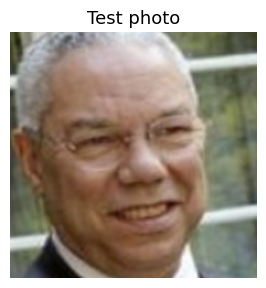

✅ 使用：demo.jpg


In [ ]:
#@title 📸 選擇測試照 { display-mode: "both" }

#@markdown **測試照檔名**（留空 = 自動用 `test/` 裡的第一張）
test_filename = ""  #@param {type:"string"}

test_files = list_images(TEST_DIR)
assert test_files, f'❌ {TEST_DIR} 裡沒有照片！放一張你的正面照進去'

if test_filename.strip():
    matches = [f for f in test_files if os.path.basename(f) == test_filename.strip()]
    assert matches, f'❌ 找不到 {test_filename}。test/ 裡有：{[os.path.basename(f) for f in test_files]}'
    TEST_PATH = matches[0]
else:
    TEST_PATH = test_files[0]

TEST_IMG = imread_unicode(TEST_PATH)
assert TEST_IMG is not None, f'❌ 讀不到 {TEST_PATH}，檔案可能壞了'

TEST_FACE = crop_face(TEST_IMG)
assert TEST_FACE is not None, '❌ 偵測不到人臉！請換一張臉更大、更正面、光線更亮的照片'

plt.figure(figsize=(3.2, 3.2))
plt.imshow(cv2.cvtColor(TEST_FACE, cv2.COLOR_BGR2RGB))
plt.title('Test photo', fontsize=13); plt.axis('off'); plt.show()
print(f'✅ 使用：{os.path.basename(TEST_PATH)}')

---
## 4️⃣ 造一個「什麼都還沒學過」的模型

**類別名稱直接從資料夾名稱來** —— 你不用打字，程式自己去掃。

模型構造就是講義第 25 頁那張圖：

```
Input Layer          Hidden Layer          Output Layer
1280 個特徵    →      64 個神經元     →      N 個答案
                     (ReLU 激活)            (N = 你有幾個資料夾)
```

> 💡 注意最後**沒有 softmax**。
> 因為 `nn.CrossEntropyLoss` 內建了 softmax —— 自己再加一次會算兩次，訓練就爛掉。
> **這是 PyTorch 新手第一名的坑。**

In [ ]:
class DoorHead(nn.Module):
    """判斷「這是誰」的小神經網路。"""

    def __init__(self, in_dim=1280, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(0.3),              # 隨機關掉 30% 神經元，防止死背
            nn.Linear(in_dim, 64),        # Hidden Layer
            nn.ReLU(),                    # Activation Function（講義 p28）
            nn.Linear(64, n_classes),     # Output Layer（輸出原始分數 logits）
        )

    def forward(self, x):
        return self.net(x)

print('✅ 模型結構定義好了（但還沒建立實例）')

✅ 模型結構定義好了（但還沒建立實例）


In [ ]:
#@title 🔧 建立模型（權重 = 隨機亂數） { display-mode: "both" }

#@markdown **放行名單** —— 要放行的資料夾名稱
#@markdown （多人用逗號分隔，例如 `me,roommate`）
#@markdown
#@markdown 用示範資料集的話，這裡填 `Colin_Powell`（就是預設值）
allow_list = "Colin_Powell"  #@param {type:"string"}

#@markdown **通過門檻** —— 信心要多高才放行
threshold = 0.85  #@param {type:"slider", min:0.5, max:0.99, step:0.01}

dataset = scan_dataset(FACES_DIR)
assert len(dataset) >= 2, '❌ 至少要 2 個資料夾（例如 我/ 和 其他人/）'

CLASSES = list(dataset.keys())                       # 類別 = 資料夾名稱
ALLOW = [s.strip() for s in allow_list.split(',') if s.strip()]
THRESHOLD = threshold

missing = [a for a in ALLOW if a not in CLASSES]
assert not missing, f'❌ 放行名單裡的 {missing} 找不到對應資料夾。現有的：{CLASSES}'

head = DoorHead(1280, len(CLASSES)).to(DEVICE)

# 明確把權重設成很小的隨機亂數，讓「訓練前什麼都不會」這件事看得見
for m in head.modules():
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        nn.init.zeros_(m.bias)

print(f'✅ 模型建好了')
print(f'   認得的類別：{CLASSES}')
print(f'   放行名單　：{ALLOW}')
print(f'   通過門檻　：信心 ≥ {THRESHOLD*100:.0f}%')
print(f'   權重數量　：{sum(p.numel() for p in head.parameters()):,} 個（目前全是隨機亂數）\n')
print('第一層權重長這樣（前 8 個數字）：')
print(head.net[1].weight.data.flatten()[:8].cpu().numpy())

✅ 模型建好了
   認得的類別：['Colin_Powell', 'others']
   放行名單　：['Colin_Powell']
   通過門檻　：信心 ≥ 85%
   權重數量　：82,114 個（目前全是隨機亂數）

第一層權重長這樣（前 8 個數字）：
[ 0.00194019  0.02161374 -0.0017205   0.0084906  -0.01924399  0.00652986
 -0.00649441 -0.00817525]


### 門禁面板

把講義第 21 頁的 `f(x) → y` 整條串起來：

```
照片 → 找到臉 → 抽特徵 → 模型判斷 → 通過 / 拒絕
```

In [ ]:
@torch.no_grad()
def scan(img_bgr, tag=''):
    """刷臉：輸入照片 x，輸出通過或拒絕 y

    整條 pipeline 就是講義第 21 頁的 f(x) → y：
        照片 → 找到臉 → 抽特徵 → 模型判斷 → 通過 / 拒絕
    """
    face = crop_face(img_bgr)
    if face is None:
        display(HTML('<h3 style="color:#FF4757">❌ 偵測不到人臉，換一張正面清楚的照片</h3>'))
        return None

    head.eval()                       # ← 關掉 Dropout！忘了這行結果會每次都不一樣
    emb = to_embedding([face])        # (1, 1280)
    logits = head(emb)                # (1, 2) 原始分數
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    i = int(probs.argmax())
    name, conf = CLASSES[i], float(probs[i])
    passed = (name in ALLOW) and (conf >= THRESHOLD)   # ALLOW = 放行名單

    _, buf = cv2.imencode('.jpg', cv2.resize(face, (200, 200)))
    b64 = b64encode(buf).decode()

    col = '#00C48C' if passed else '#FF4757'
    bg = '#E8FBF4' if passed else '#FFECEE'
    verdict = '✅ 通 過' if passed else '⛔ 拒 絕'
    if passed:
        msg = '歡迎回來，' + name
    elif name in ALLOW:
        msg = '信心不足 —— 我覺得有點像 ' + name + '，但不夠確定'
    else:
        msg = '你不在放行名單上（我覺得你是「' + name + '」）'

    bars = ''
    for c, p in zip(CLASSES, probs):
        pct = '%.1f' % (p * 100)
        bars += (
            '<div style="margin:7px 0;font:13px system-ui">'
            '<div style="display:flex;justify-content:space-between">'
            '<b>' + c + '</b><span style="color:#7A849C">' + pct + '%</span></div>'
            '<div style="background:#EEF1F6;border-radius:6px;height:11px;margin-top:3px">'
            '<div style="background:' + col + ';width:' + pct + '%;'
            'height:11px;border-radius:6px"></div></div></div>'
        )

    thr = '%.0f' % (THRESHOLD * 100)
    display(HTML(
        '<div style="border:3px solid ' + col + ';background:' + bg + ';border-radius:16px;'
        'padding:20px;max-width:560px;font-family:system-ui;margin:10px 0">'
        '<div style="font-size:13px;color:#7A849C;letter-spacing:2px">' + tag + '</div>'
        '<div style="display:flex;gap:20px;align-items:center;margin-top:10px">'
        '<img src="data:image/jpeg;base64,' + b64 + '" '
        'style="width:130px;height:130px;border-radius:12px;object-fit:cover">'
        '<div style="flex:1">'
        '<div style="font-size:30px;font-weight:800;color:' + col + '">' + verdict + '</div>'
        '<div style="font-size:14px;color:#16213E;margin:6px 0 12px">' + msg + '</div>'
        + bars +
        '<div style="font-size:11px;color:#7A849C;margin-top:8px">通過門檻 = ' + thr + '%</div>'
        '</div></div></div>'
    ))
    return passed


print('✅ 門禁面板就緒')

✅ 門禁面板就緒


---
## 🔴 5️⃣ 第一次刷臉（訓練前）

**執行前先猜一下：會發生什麼事？**

模型權重是隨機亂數，它對「你是誰」完全沒概念 ——
每個答案機率差不多，遠遠達不到門檻。

按下去。


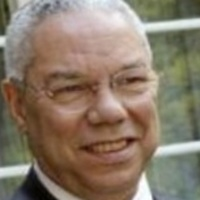

False

In [ ]:
scan(TEST_IMG, tag='第 1 次刷臉 ── 訓練前')

### 被擋下來了 —— 為什麼？

因為權重是**隨機的**。它不是「不認識你」，它是**什麼都不認識**。

> 🧠 **這裡是重點：**
> 這個模型已經有完整的結構（層數、神經元、激活函數全都在），
> 而且從現在開始，程式碼一行都不會再改。
> **缺的只有那 82,000 個權重的「正確數值」。**
>
> 接下來要做的，就是用資料把這些數字調到對的位置 —— **這就是訓練。**

---
## 6️⃣ 讀資料 + 抽特徵

這是**監督式學習**（講義第 23 頁）：每一張照片都要有標準答案。

**你的標準答案就是資料夾名稱** —— 你把照片拖進 `我/` 的那個動作，就是在標註。

> 💡 想想看：如果今天要做的是 1000 個人的門禁，你要拖幾次？
> 這就是為什麼講義說「標註資料有時候要人工標註，成本較高」。

In [ ]:
X_img, y_label, skipped = [], [], []

for name in CLASSES:
    files = dataset[name]
    ok = 0
    for path in files:
        face = crop_face(imread_unicode(path))
        if face is None:
            skipped.append(os.path.basename(path)); continue
        X_img.append(face); y_label.append(name); ok += 1
    print(f'  {name:<10} {ok:>3} / {len(files):<3} 張成功偵測到臉')

y_label = np.array(y_label)
print(f'\n✅ 共切出 {len(X_img)} 張人臉')

if skipped:
    print(f'\n⚠️ 有 {len(skipped)} 張偵測不到臉（側臉、太暗、臉太小、沒有人臉）：')
    for f in skipped[:8]:
        print(f'     • {f}')
    if len(skipped) > 8:
        print(f'     …還有 {len(skipped)-8} 張')

for c in CLASSES:
    assert (y_label == c).sum() >= 8, f'❌ 「{c}」能用的照片太少，請多放一些正面清楚的'

  Colin_Powell  25 / 25  張成功偵測到臉
  others      39 / 40  張成功偵測到臉

✅ 共切出 64 張人臉

⚠️ 有 1 張偵測不到臉（側臉、太暗、臉太小、沒有人臉）：
     • 023.jpg


### 看一下模型會看到什麼

**請認真看下面的圖。** 切歪了、切到牆壁、或哪一類特別少 —— 模型就會學壞。

> **Garbage in, garbage out.** 這是資料科學最古老的定律。

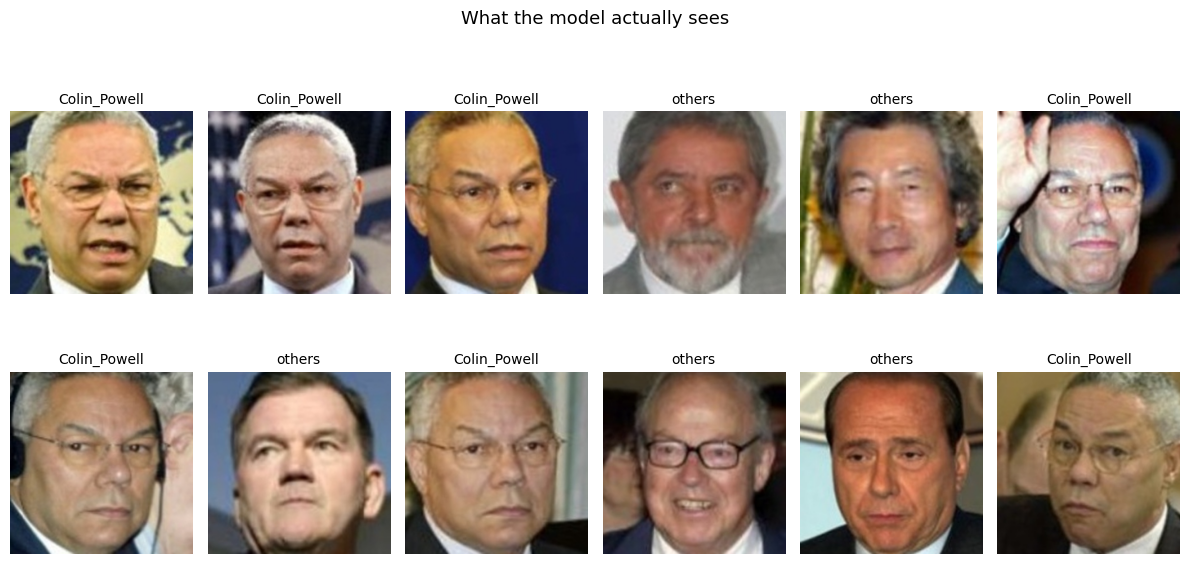

每一類的資料量：
  Colin_Powell  25 張  ████████████
  others      39 張  ███████████████████


In [ ]:
n_show = min(12, len(X_img))
idx = np.random.choice(len(X_img), n_show, replace=False)
plt.figure(figsize=(12, 3.2 * ((n_show + 5) // 6)))
for i, j in enumerate(idx):
    plt.subplot((n_show + 5) // 6, 6, i + 1)
    plt.imshow(cv2.cvtColor(X_img[j], cv2.COLOR_BGR2RGB))
    plt.title(y_label[j], fontsize=10); plt.axis('off')
plt.suptitle('What the model actually sees', fontsize=13)
plt.tight_layout(); plt.show()

print('每一類的資料量：')
for c in CLASSES:
    k = (y_label == c).sum()
    print(f'  {c:<10} {k:>3} 張  {"█" * (k // 2)}')

In [ ]:
from sklearn.model_selection import train_test_split

# 資料增強：左右翻轉，資料量免費變兩倍
# .copy() 是必要的 —— numpy 翻轉後 stride 會變負數，PyTorch 的 from_numpy 會直接拒絕
X_all = X_img + [f[:, ::-1, :].copy() for f in X_img]
y_all = np.concatenate([y_label, y_label])

print('正在抽特徵…')
t0 = time.time()
E = to_embedding(X_all).cpu()
y_num = torch.tensor([CLASSES.index(c) for c in y_all], dtype=torch.long)
print(f'✅ 完成，{time.time()-t0:.1f} 秒')
print(f'   {len(X_all)} 張照片 → 特徵張量 {tuple(E.shape)}')

# 切 20% 當考卷 —— 模型沒看過的資料，才能檢驗它是真的學會還是死背
idx_tr, idx_te = train_test_split(
    np.arange(len(E)), test_size=0.2, random_state=42, stratify=y_num.numpy())

train_loader = DataLoader(TensorDataset(E[idx_tr], y_num[idx_tr]), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(E[idx_te], y_num[idx_te]), batch_size=32)
print(f'   訓練 {len(idx_tr)} 筆 | 測試 {len(idx_te)} 筆')

正在抽特徵…
✅ 完成，0.4 秒
   128 張照片 → 特徵張量 (128, 1280)
   訓練 102 筆 | 測試 26 筆


---
## 7️⃣ 訓練：把亂數調成「對的數字」

### 講義第 30 頁那張圖，就是下面這五行

| 講義上的步驟 | PyTorch 程式碼 |
|---|---|
| 照片 → model → **預測種類** | `logits = head(xb)` |
| 預測 vs 真實 → **損失函數** | `loss = criterion(logits, yb)` |
| （先把上一輪的梯度清掉） | `optimizer.zero_grad()` |
| **Backpropagation**（紅色箭頭） | `loss.backward()` |
| **更新權重** | `optimizer.step()` |

**訓練迴圈是你自己寫的，每一行都對得上講義那張圖。沒有東西被藏起來。**

> ⚠️ **`optimizer.zero_grad()` 不能忘。**
> PyTorch 的梯度是**累加**的，不會自動歸零。忘記寫的話，這一輪的梯度會加到上一輪上面 ——
> **而且不會報錯**，只是結果爛掉，超難抓。這是 PyTorch 第一名的坑。

In [ ]:
criterion = nn.CrossEntropyLoss()          # 分類問題用 Cross Entropy（講義 p31）
optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)
EPOCHS = 40

hist = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(1, EPOCHS + 1):
    # ── 訓練 ──
    head.train()                           # 打開 Dropout
    tl, tc, tn = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        logits = head(xb)                  # ① 預測
        loss = criterion(logits, yb)       # ② 算損失：差多少？

        optimizer.zero_grad()              # ③ 清掉上一輪的梯度（別忘了！）
        loss.backward()                    # ④ Backpropagation：算出每個權重該往哪動
        optimizer.step()                   # ⑤ 更新權重

        tl += loss.item() * len(xb)
        tc += (logits.argmax(1) == yb).sum().item()
        tn += len(xb)

    # ── 驗證（不訓練，只是看看考幾分）──
    head.eval()                            # 關掉 Dropout
    vl, vc, vn = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = head(xb)
            vl += criterion(logits, yb).item() * len(xb)
            vc += (logits.argmax(1) == yb).sum().item()
            vn += len(xb)

    hist['train_loss'].append(tl / tn); hist['test_loss'].append(vl / vn)
    hist['train_acc'].append(tc / tn);  hist['test_acc'].append(vc / vn)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>2}/{EPOCHS}  loss {tl/tn:.4f}  acc {tc/tn*100:5.1f}%'
              f'  |  驗證 loss {vl/vn:.4f}  acc {vc/vn*100:5.1f}%')

print('\n🎉 訓練完成 —— 權重已經不是亂數了')
print('再看一次第一層權重（跟訓練前比比看）：')
print(head.net[1].weight.data.flatten()[:8].cpu().numpy())

Epoch  1/40  loss 0.6791  acc  60.8%  |  驗證 loss 0.6474  acc  61.5%
Epoch  5/40  loss 0.3465  acc  90.2%  |  驗證 loss 0.3694  acc  88.5%
Epoch 10/40  loss 0.0908  acc  99.0%  |  驗證 loss 0.1603  acc  88.5%
Epoch 15/40  loss 0.0431  acc  99.0%  |  驗證 loss 0.0629  acc 100.0%
Epoch 20/40  loss 0.0251  acc 100.0%  |  驗證 loss 0.0385  acc 100.0%
Epoch 25/40  loss 0.0186  acc 100.0%  |  驗證 loss 0.0273  acc 100.0%
Epoch 30/40  loss 0.0142  acc 100.0%  |  驗證 loss 0.0236  acc 100.0%
Epoch 35/40  loss 0.0164  acc 100.0%  |  驗證 loss 0.0172  acc 100.0%
Epoch 40/40  loss 0.0053  acc 100.0%  |  驗證 loss 0.0229  acc 100.0%

🎉 訓練完成 —— 權重已經不是亂數了
再看一次第一層權重（跟訓練前比比看）：
[ 0.06218155 -0.002244    0.00433183 -0.00371539 -0.0128672   0.03718787
 -0.06098304  0.00511348]


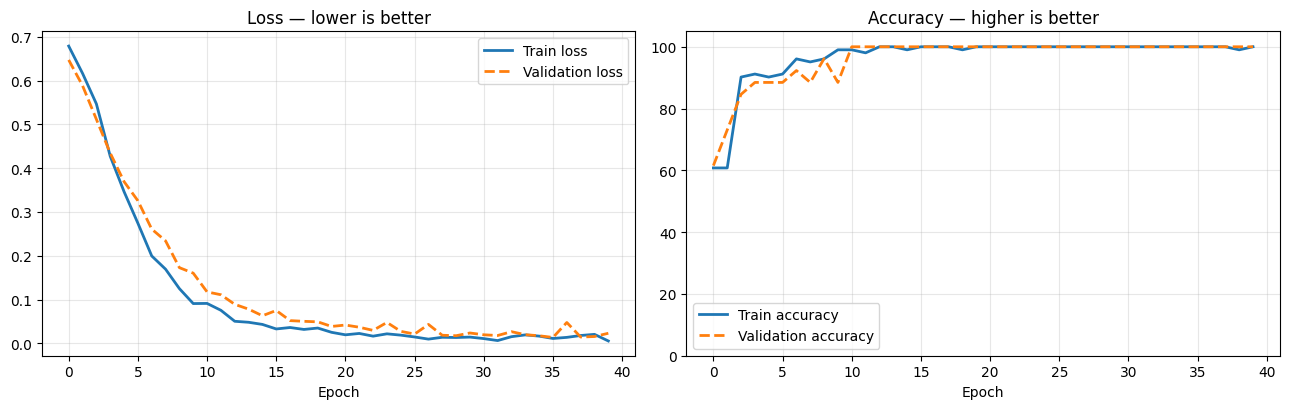

📊 在沒看過的測試資料上：準確率 100.0% | loss 0.0229


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# 圖表文字一律用英文 —— Colab 預設沒有中文字型，中文會變成豆腐字 □□□
axes[0].plot(hist['train_loss'], lw=2, label='Train loss')
axes[0].plot(hist['test_loss'], lw=2, ls='--', label='Validation loss')
axes[0].set_title('Loss — lower is better'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(np.array(hist['train_acc']) * 100, lw=2, label='Train accuracy')
axes[1].plot(np.array(hist['test_acc']) * 100, lw=2, ls='--', label='Validation accuracy')
axes[1].set_title('Accuracy — higher is better'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 105); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"📊 在沒看過的測試資料上：準確率 {hist['test_acc'][-1]*100:.1f}% | loss {hist['test_loss'][-1]:.4f}")

**怎麼讀左邊那張圖：**

- 兩條線都往下 ✅ → 學得很好
- 訓練 loss 一直掉，但驗證 loss 開始往上翹 ⚠️ → **overfitting**，開始死背答案了
- 兩條都很高不動 ❌ → 資料太少或太亂，回去多放一些照片

---
## 🟢 8️⃣ 第二次刷臉（訓練後）

**同一張照片。同一個 `head` 物件。同一行程式碼。**

往上滑回去比對 —— 第 5 步跟現在，`scan(TEST_IMG)` 一個字都沒改。

按下去。


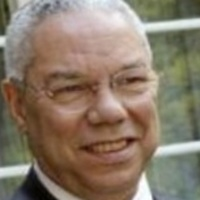

True

In [ ]:
scan(TEST_IMG, tag='第 2 次刷臉 ── 訓練後')

### 🎉 通過了

| | 訓練前 | 訓練後 |
|---|---|---|
| 照片 | 一模一樣 | 一模一樣 |
| 程式碼 | 一模一樣 | 一模一樣 |
| 模型結構 | 一模一樣 | 一模一樣 |
| **權重的數值** | **隨機亂數** | **被資料調整過** |
| 結果 | ❌ 拒絕 | ✅ 通過 |

> **所以「AI 模型」到底是什麼？** 就是那 82,000 個數字。
> 存下來就是一個 `.pt` 檔案。你把檔案傳給別人，別人就有了「認得你的臉」這個能力。
>
> 講義第 21 頁說「AI 只是一個 function」—— 現在你知道那個 function 是怎麼長出來的了。

---
## 9️⃣ 壓力測試：現在來玩壞它

**能通過很無聊。真正學到東西的地方，是它出錯的時候。**

把 `test/` 裡的其他照片拿來刷刷看。

In [ ]:
#@title 🕵️ 刷 test/ 裡的其他照片 { display-mode: "both" }

#@markdown **要刷哪一張？**（填 `test/` 資料夾裡的檔名）
scan_filename = "stranger.jpg"  #@param {type:"string"}

matches = [f for f in list_images(TEST_DIR) if os.path.basename(f) == scan_filename.strip()]
if not matches:
    print(f'❌ 找不到 {scan_filename}。test/ 裡有：')
    for f in list_images(TEST_DIR):
        print(f'   • {os.path.basename(f)}')
else:
    scan(imread_unicode(matches[0]), tag=f'測試 ── {scan_filename}')

### 測試 A：陌生人闖進來了嗎？

**如果陌生人被放行了，恭喜 —— 你剛剛親手發現了一個真實的資安漏洞。**

原因是：模型只學過你給的那幾類。如果 `others/` 的資料不夠多樣，
模型學到的可能只是「凡是不像那幾個人的，就算是你」。

**這叫 open-set 問題**，是人臉辨識最難的部分之一。
真正的門禁不會用「分類」來做，而是比對特徵向量的**距離** ——
太遠就一律拒絕，不管像誰。

👉 **回去往 `others/` 多丟幾個不同的人，重跑一次，再測。看看有沒有改善。**

### 測試 B：其他攻擊

往 `test/` 資料夾多丟幾張，回上面那格改檔名再刷：

| 試試看 | 你猜會怎樣？ |
|---|---|
| 🖼️ **拿手機顯示你的照片，再拍一張照** | |
| 🕶️ 戴墨鏡 / 口罩 / 帽子 | |
| 💡 很暗的照片 | |
| 🙃 側臉 45 度 | |
| 👶 你小時候的照片 | |
| 👯 跟你長得很像的兄弟姊妹 | |

> 💭 **第一項特別重要。**
> 如果拍照片就能刷過門禁，那這系統一點用都沒有 —— 這叫 **presentation attack**。
> 真實門禁要靠紅外線、3D 深度、或要求你眨眼（liveness detection）來擋。
>
> **你剛剛做的東西，離「能用」還很遠。這件事值得記住。**

---
## 💾 存下你的模型

PyTorch 的慣例是**只存權重**（`state_dict`），不存整個物件 ——
存整個物件會把 class 定義一起 pickle 進去，換個環境就可能讀不出來。

模型會存進你的資料夾，所以**跟照片一樣會永久留著**。

In [ ]:
MODEL_PATH = os.path.join(ROOT, 'door_model.pt')

torch.save({
    'state_dict': head.state_dict(),
    'classes': CLASSES,
    'allow': ALLOW,
    'threshold': THRESHOLD,
}, MODEL_PATH)

print(f'✅ 已存檔：{MODEL_PATH}（{os.path.getsize(MODEL_PATH)/1024:.0f} KB）')
print(f'   這個檔案 = 「認得 {ALLOW} 的臉」這個能力\n')

# ── 驗證真的存對了：建一個全新的空模型，把權重載進去 ──
head.eval()          # 關掉 Dropout，不然兩次預測會不一樣
ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
head2 = DoorHead(1280, len(ckpt['classes'])).to(DEVICE)
head2.load_state_dict(ckpt['state_dict'])
head2.eval()

with torch.no_grad():
    emb = to_embedding([TEST_FACE])
    p1 = torch.softmax(head(emb), dim=1)
    p2 = torch.softmax(head2(emb), dim=1)
print('原模型預測：', p1[0].cpu().numpy().round(4))
print('讀檔後預測：', p2[0].cpu().numpy().round(4))
print('完全一致 ✅' if torch.allclose(p1, p2) else '❌ 不一致，有問題')

---
## 🎓 回顧

```
     x                                                       y
   照片 → ① 找到臉 → ② 抽特徵 → ③ 判斷是誰 → 通過 / 拒絕
            Haar        MobileNetV2   DoorHead
            傳統演算法   凍結、借來的   你訓練的 82,000 個數字
   └─────────────────── 這整條就是 f ───────────────────┘
```

**三個帶得走的重點：**

1. **模型 = 一堆數字。** 訓練前後唯一的差別就是這些數字。
2. **資料決定一切。** 你花在挑照片、拖資料夾的時間，遠比訓練那幾秒久 ——
   這就是真實 AI 專案的比例。而且「其他人」的資料品質，比「你」的更關鍵。
3. **能動 ≠ 能用。** 你的門禁被一張照片就騙過了。
   **知道自己的東西哪裡會壞，比讓它跑起來更重要。**

---

## 🚀 延伸挑戰

- **加第三個人**：在 `faces/` 開一個 `roommate/` 資料夾丟照片進去，
  重跑「建立模型」那格。**程式碼要改幾行？答案：0 行。**
  （想讓室友也能進門？把 `allow_list` 改成 `me,roommate`）
- **改善 open-set 問題**：不要用分類，改算**特徵距離** ——
  用 `torch.nn.functional.cosine_similarity` 比對測試照跟所有「放行照片」的特徵，
  取最大值，低於門檻就拒絕。這才是真實系統的做法。
- **Fine-tune backbone**：把 `backbone.features[-3:]` 解凍（`requires_grad = True`），
  用**很小的 learning rate**（`1e-5`）訓練。準確率會不會更好？小心 overfitting。
- **真的資料增強**：現在只做了左右翻轉。試試 `RandomRotation`、`ColorJitter`、
  `RandomResizedCrop`，包成自己的 `Dataset`。
  （提示：這樣就不能預先算好特徵了，為什麼？）
- **調門檻**：從 0.85 拉到 0.99，誤放行變少，但你自己可能也進不去 ——
  這個取捨叫 **precision vs recall**，所有 AI 系統都躲不掉。

---

## ⚖️ 最後

你剛剛用免費工具、20 分鐘，做了一個會認人的系統。

**門檻這麼低，代表任何人都做得到 —— 包含用它做壞事的人。**

密碼外洩可以改，臉外洩了改不了。
如果你的黑客松作品會碰到人臉，請先想清楚：**誰同意了？存在哪？怎麼刪？**

> ⚠️ **注意：你的照片現在存在 Google Drive 裡，不會自動消失。**
> 課程結束後想清掉的話，執行下面這格（或直接去 Drive 裡刪掉那個資料夾）。

In [ ]:
#@title 🗑️ 刪除所有照片與模型
confirm = False #@param {type:"boolean"}

if confirm:
    shutil.rmtree(ROOT, ignore_errors=True)
    print(f'✅ 已刪除 {ROOT}')
else:
    print(f'請把 confirm 打勾再執行。將會刪除：{ROOT}')